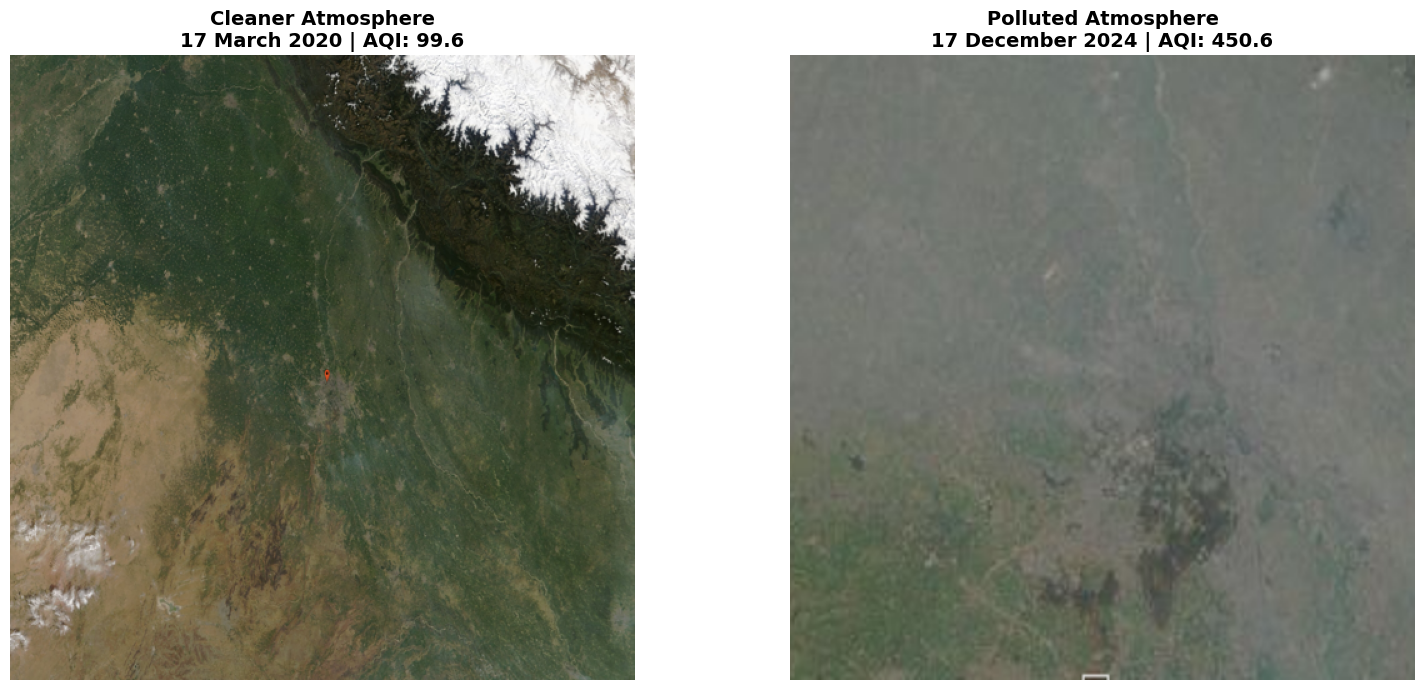

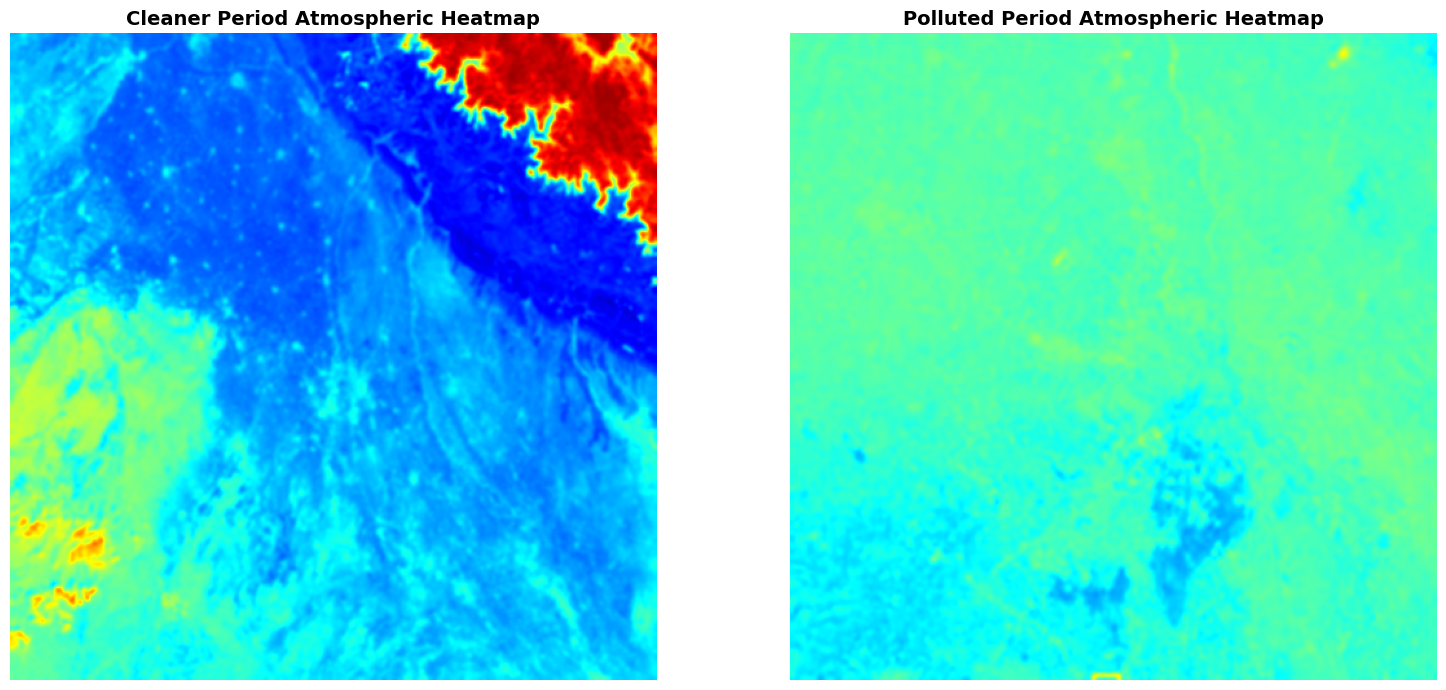

SATELLITE VISUAL INTELLIGENCE SUMMARY
Cleaner period AQI (17 Mar 2020): 99.6
Polluted period AQI (17 Dec 2024): 450.6
Visual comparison indicates significantly reduced atmospheric clarity in polluted period.
Satellite heatmap highlights denser atmospheric disturbance during high AQI conditions.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

plt.style.use('ggplot')

# ==========================================
# PATHS
# ==========================================

csv_path = r"C:\Users\hi\Desktop\AQI MAJOR PROJECT\data\cleaned_aqi_final.csv"

clean_image_path = r"C:\Users\hi\Desktop\AQI MAJOR PROJECT\satellite images\2020\march\2020-03-17.png"
polluted_image_path = r"C:\Users\hi\Desktop\AQI MAJOR PROJECT\satellite images\2024\december\2024-12-17.png"

# ==========================================
# LOAD AQI DATA
# ==========================================

df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Date'])

aqi_2020 = df[df['Date'] == '2020-03-17']['AQI'].values[0]
aqi_2024 = df[df['Date'] == '2024-12-17']['AQI'].values[0]

# ==========================================
# SATELLITE ANALYSIS FUNCTION
# ==========================================

def process_satellite(path):
    img = Image.open(path).convert('RGB')
    img = img.resize((500, 500))
    img_np = np.array(img)

    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    blur = cv2.GaussianBlur(gray, (7, 7), 0)

    heatmap = cv2.applyColorMap(blur, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    return img_np, heatmap

# ==========================================
# PROCESS IMAGES
# ==========================================

clean_img, clean_heatmap = process_satellite(clean_image_path)
polluted_img, polluted_heatmap = process_satellite(polluted_image_path)

# ==========================================
# SATELLITE IMAGE COMPARISON
# ==========================================

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
plt.imshow(clean_img)
plt.title(
    f"Cleaner Atmosphere\n17 March 2020 | AQI: {aqi_2020}",
    fontsize=14,
    fontweight='bold'
)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(polluted_img)
plt.title(
    f"Polluted Atmosphere\n17 December 2024 | AQI: {aqi_2024}",
    fontsize=14,
    fontweight='bold'
)
plt.axis('off')

plt.tight_layout()
plt.show()

# ==========================================
# HEATMAP COMPARISON
# ==========================================

plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
plt.imshow(clean_heatmap)
plt.title(
    "Cleaner Period Atmospheric Heatmap",
    fontsize=14,
    fontweight='bold'
)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(polluted_heatmap)
plt.title(
    "Polluted Period Atmospheric Heatmap",
    fontsize=14,
    fontweight='bold'
)
plt.axis('off')

plt.tight_layout()
plt.show()

# ==========================================
# SMART SUMMARY
# ==========================================

print("="*65)
print("SATELLITE VISUAL INTELLIGENCE SUMMARY")
print("="*65)
print(f"Cleaner period AQI (17 Mar 2020): {aqi_2020}")
print(f"Polluted period AQI (17 Dec 2024): {aqi_2024}")
print("Visual comparison indicates significantly reduced atmospheric clarity in polluted period.")
print("Satellite heatmap highlights denser atmospheric disturbance during high AQI conditions.")
print("="*65)